In [19]:
import pandas as pd

In [20]:
df = pd.read_csv(r'..\data\train_sample.csv')

In [21]:
print("Information of data")
df.info()

print()
print("Data types of each column")
df.dtypes

Information of data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94641 entries, 0 to 94640
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     94641 non-null  int64  
 1   Login Timestamp           94641 non-null  object 
 2   User ID                   94641 non-null  int64  
 3   Round-Trip Time [ms]      3896 non-null   float64
 4   IP Address                94641 non-null  object 
 5   Country                   94641 non-null  object 
 6   Region                    94481 non-null  object 
 7   City                      94615 non-null  object 
 8   ASN                       94641 non-null  int64  
 9   User Agent String         94641 non-null  object 
 10  Browser Name and Version  94641 non-null  object 
 11  OS Name and Version       94641 non-null  object 
 12  Device Type               94638 non-null  object 
 13  Login Successful          94641 non-null 

index                         int64
Login Timestamp              object
User ID                       int64
Round-Trip Time [ms]        float64
IP Address                   object
Country                      object
Region                       object
City                         object
ASN                           int64
User Agent String            object
Browser Name and Version     object
OS Name and Version          object
Device Type                  object
Login Successful               bool
Is Attack IP                   bool
Is Account Takeover            bool
dtype: object

In [22]:
print("Missing values in every column")
df.isnull().sum()

Missing values in every column


index                           0
Login Timestamp                 0
User ID                         0
Round-Trip Time [ms]        90745
IP Address                      0
Country                         0
Region                        160
City                           26
ASN                             0
User Agent String               0
Browser Name and Version        0
OS Name and Version             0
Device Type                     3
Login Successful                0
Is Attack IP                    0
Is Account Takeover             0
dtype: int64

Cleaning the data

In [23]:
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,4206188,2020-03-31 18:22:31.446,-1751455383105469063,NaN,31.185.24.172,NO,Viken,Gjerdrum,2116,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.0.0.2416,iOS 7.1,mobile,True,False,False
1,2385020,2020-03-06 02:54:37.898,8397202535583890606,NaN,80.211.249.38,PL,Mazovia,Warsaw,205727,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044,iOS 13.4,mobile,True,False,False
2,6769730,2020-05-06 08:27:20.512,-4324475583306591935,NaN,77.72.57.141,FI,Uusimaa,Helsinki,42252,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile 81.0.4044.1926,iOS 11.2.6,mobile,False,False,False
3,333230,2020-02-07 19:00:21.044,6558541938824566943,NaN,150.214.0.15,SC,-,-,198096,Mozilla/5.0 (iPhone; CPU iPhone OS 13_1_3 lik...,Chrome Mobile 81.0.4044.2180,iOS 13.1.3,mobile,True,False,False
4,15159021,2020-09-01 09:49:28.481,-4324475583306591935,NaN,92.48.79.232,GB,-,-,29550,Mozilla/5.0 (iPad; CPU OS 5_1_1 like Mac OS X...,Android 2.3.3.2660,iOS 5.1.1,mobile,False,False,False


In [24]:
# 1) Drop useless cols
df.drop(columns=['Round-Trip Time [ms]', 'index'], inplace=True)

# 2) Filling small gaps
df['Region'] = df['Region'].fillna('Unknown')
df['City'] = df['City'].fillna('Unknown')
df['Device Type'] = df['Device Type'].fillna('Unknown')

# 3) Fixing data types
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])

print("Post cleaning data stats")
df.info()
print()
df.dtypes
print()
df.isnull().sum()

Post cleaning data stats
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94641 entries, 0 to 94640
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Login Timestamp           94641 non-null  datetime64[ns]
 1   User ID                   94641 non-null  int64         
 2   IP Address                94641 non-null  object        
 3   Country                   94641 non-null  object        
 4   Region                    94641 non-null  object        
 5   City                      94641 non-null  object        
 6   ASN                       94641 non-null  int64         
 7   User Agent String         94641 non-null  object        
 8   Browser Name and Version  94641 non-null  object        
 9   OS Name and Version       94641 non-null  object        
 10  Device Type               94641 non-null  object        
 11  Login Successful          94641 non-null  bool         

Login Timestamp             0
User ID                     0
IP Address                  0
Country                     0
Region                      0
City                        0
ASN                         0
User Agent String           0
Browser Name and Version    0
OS Name and Version         0
Device Type                 0
Login Successful            0
Is Attack IP                0
Is Account Takeover         0
dtype: int64

In [26]:
print("Account takeover vs Login success")
print(pd.crosstab(df['Is Account Takeover'], df['Login Successful']))

Account takeover vs Login success
Login Successful     False  True 
Is Account Takeover              
False                56406  38094
True                     1    140


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

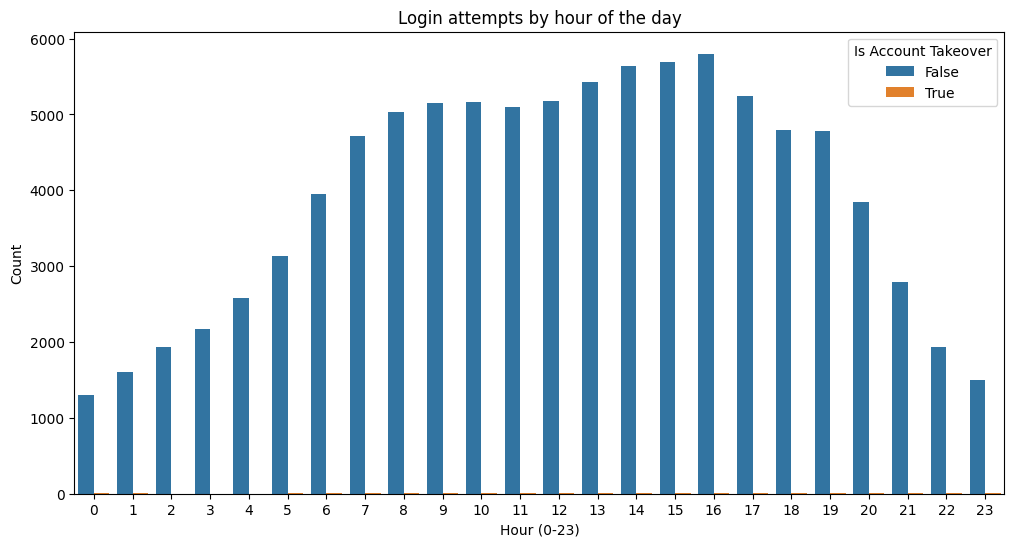

In [40]:
# Extracting hour from timestamp
df['hour'] = df['Login Timestamp'].dt.hour

# Plotting distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='hour', hue='Is Account Takeover')
plt.title('Login attempts by hour of the day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')
plt.show()

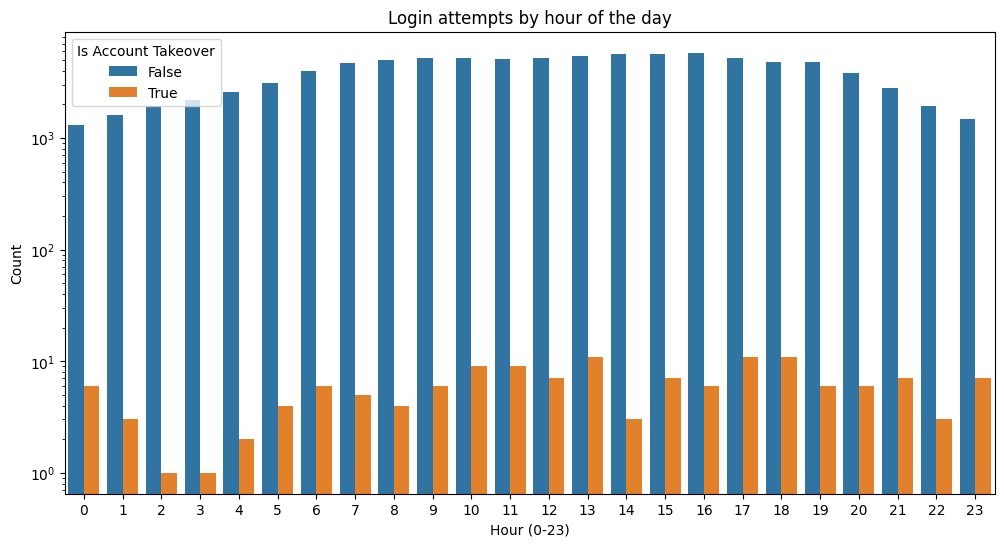

In [41]:
# Extracting hour from timestamp
df['hour'] = df['Login Timestamp'].dt.hour

# Plotting distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='hour', hue='Is Account Takeover')
plt.title('Login attempts by hour of the day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

In [45]:
hacks = df[df['Is Account Takeover'] == True]
country_counts = hacks['Country'].value_counts()

print("Top countries for account takeovers:")
print(country_counts)

Top countries for account takeovers:
Country
RO    79
NO    10
ID     9
CA     9
BR     9
IT     7
DK     5
CL     3
LV     3
CZ     2
RE     1
SK     1
MZ     1
AR     1
NL     1
Name: count, dtype: int64


In [48]:
print("Top browsers from where attacks originate")
print(hacks['Browser Name and Version'].value_counts())

Top browsers from where attacks originate
Browser Name and Version
Chrome 79.0.3945.192.218        89
Chrome 79.0.3945.192.205         9
Chrome Mobile 81.0.4044.1950     6
Chrome 69.0.3497.17.20           3
Chrome Mobile 81.0.4044.1934     3
Chrome 69.0.3497.17.21           2
Chrome 79.0.3945.192.198         2
Chrome 72.0.3626.54              1
Edge 81.0.416                    1
Chrome Mobile 81.0.4044.1930     1
Chrome 79.0.3945.192.203         1
Chrome 73.0.3654                 1
Chrome 72.0.3626.51              1
Chrome 72.0.3626.74              1
Chrome 72.0.3626.68              1
Chrome 67.0.3396                 1
Chrome Mobile 81.0.4044          1
Chrome 79.0.3945.192.202         1
Android 2.3.6                    1
Firefox 20.0.0.1673              1
Chrome 79.0.3945.192.207         1
Chrome Mobile 81.0.4044.2216     1
Chrome 71.0.3578.37              1
Chrome 79.0.3945.192             1
Chrome 79.0.3945.192.201         1
Opera Mobile 52.1.2254.2306      1
Chrome Mobile 81.0.4044

In [50]:
print("Top ASNs from where attacks originate:")
print(hacks['ASN'].value_counts())

Top ASNs from where attacks originate:
ASN
206801    18
197175    16
62350     15
197475     7
61353      7
3280       7
41560      5
31028      4
197357     4
501775     4
266130     4
136862     4
48874      3
29695      3
503109     2
59701      2
41496      2
13209      2
393713     2
63490      2
62160      2
41197      2
51656      1
43443      1
502899     1
504288     1
207674     1
50245      1
20616      1
137308     1
51177      1
29492      1
500208     1
60989      1
500194     1
39569      1
50427      1
61157      1
57423      1
59784      1
46034      1
505051     1
56851      1
34723      1
500106     1
266128     1
Name: count, dtype: int64
